In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.7
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abb

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.656 s
Baseline,off


Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
combining channels using "gfp"


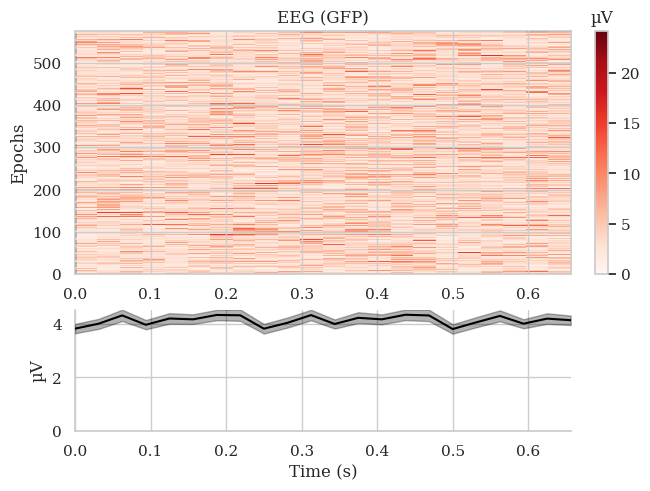

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_2395/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 22)

In [7]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import combine_pvalues
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=1,
    max_iter=128,
    tol=1e-8,
    init ='svd',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lanczos',
    taper=True,
    keep_train_info=True,
    verbose=True,
)


hoda.fit(X,y)
hoda

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...


HODA(keep_train_info=True, max_iter=128, rank=1, taper=True, verbose=True)

In [8]:
hoda.train_info_

,F_tr,F_rt,mse,log_like,bic,aic,aicc,update
iteration,,,,,,,,
0.0,0.362513,0.001259,2.182882e-11,-207.582965,421.522038,417.165931,417.172899,8.825818e-02
1.0,0.587839,0.002041,2.113795e-11,-180.378110,367.112328,362.756220,362.763189,7.056481e-02
2.0,0.601432,0.002088,2.174694e-11,-179.288038,364.932184,360.576076,360.583045,2.920613e-02
3.0,0.736371,0.002557,2.154693e-11,-165.603335,337.562777,333.206670,333.213638,3.109934e-02
4.0,0.762945,0.002649,2.166525e-11,-162.425301,331.206710,326.850603,326.857571,2.769997e-02
5.0,0.929398,0.003227,2.160502e-11,-147.214940,300.785987,296.429879,296.436848,2.486964e-02
6.0,0.995805,0.003458,2.159685e-11,-140.087390,286.530888,282.174781,282.181749,1.943844e-02
7.0,1.162606,0.004037,2.159993e-11,-126.440858,259.237823,254.881715,254.888684,1.461619e-02
8.0,1.228910,0.004267,2.157336e-11,-120.116497,246.589101,242.232993,242.239962,9.552702e-03


In [9]:
hoda.mode_train_info_

objective  shrinkage  rank        update
iteration mode                                             
0.0       0.0   4.383210e+09   0.004525   1.0  1.207389e-01
          1.0   8.961396e+06   0.054682   1.0  6.451531e-02
1.0       0.0   2.209564e+10   0.005613   1.0  3.639841e-02
          1.0   3.812091e+11   0.104649   1.0  1.368024e-01
2.0       0.0   2.578622e+10   0.005282   1.0  2.120800e-02
          1.0   2.151456e+11   0.067319   1.0  4.022057e-02
3.0       0.0   1.977394e+10   0.005348   1.0  3.201903e-02
          1.0   2.758032e+11   0.092926   1.0  3.020607e-02
4.0       0.0   2.788762e+10   0.005567   1.0  2.081682e-02
          1.0   3.427985e+11   0.085238   1.0  3.685906e-02
5.0       0.0   1.847050e+10   0.005444   1.0  2.469615e-02
          1.0   2.857644e+11   0.090555   1.0  2.504434e-02
6.0       0.0   2.472283e+10   0.005742   1.0  1.333033e-02
          1.0   3.921335e+11   0.090313   1.0  2.834534e-02
7.0       0.0   1.820941e+10   0.005454   1.0  1.469372e-02
          1.0   2.935575e+11   0.090534   1.0  1.453907e-02
8.0       0.0   2.068300e+10   0.005808   1.0  5.816159e-03
          1.0   4.099514e+11   0.091526   1.0  1.568976e-02
9.0       0.0   1.819329e+10   0.005450   1.0  6.256858e-03
          1.0   3.202238e+11   0.091141   1.0  4.967964e-03
10.0      0.0   1.821604e+10   0.005706   1.0  1.762383e-03
          1.0   4.165888e+11   0.091810   1.0  5.273575e-03
11.0      0.0   1.820995e+10   0.005447   1.0  1.877991e-03
          1.0   3.578170e+11   0.091759   1.0  1.107133e-03
12.0      0.0   1.773576e+10   0.005570   1.0  4.212560e-04
          1.0   4.193025e+11   0.091870   1.0  1.171454e-03
13.0      0.0   1.822328e+10   0.005444   1.0  4.469357e-04
          1.0   3.865048e+11   0.091997   1.0  2.136024e-04
14.0      0.0   1.790549e+10   0.005497   1.0  8.931920e-05
          1.0   4.204683e+11   0.091879   1.0  2.259762e-04
15.0      0.0   1.823077e+10   0.005443   1.0  9.456541e-05
          1.0   4.039785e+11   0.092006   1.0  4.043982e-05
16.0      0.0   1.807139e+10   0.005465   1.0  1.790134e-05
          1.0   4.209786e+11   0.091878   1.0  4.278438e-05
17.0      0.0   1.823452e+10   0.005443   1.0  1.893595e-05
          1.0   4.132346e+11   0.091961   1.0  7.672463e-06
18.0      0.0   1.816099e+10   0.005452   1.0  3.497692e-06
          1.0   4.212034e+11   0.091876   1.0  8.117281e-06
19.0      0.0   1.823630e+10   0.005442   1.0  3.698691e-06
          1.0   4.176991e+11   0.091922   1.0  1.459768e-06
20.0      0.0   1.820337e+10   0.005447   1.0  6.756252e-07
          1.0   4.213024e+11   0.091875   1.0  1.544382e-06
21.0      0.0   1.823713e+10   0.005442   1.0  7.144062e-07
          1.0   4.197456e+11   0.091898   1.0  2.782358e-07
22.0      0.0   1.822256e+10   0.005444   1.0  1.298176e-07
          1.0   4.213460e+11   0.091874   1.0  2.943612e-07
23.0      0.0   1.823750e+10   0.005442   1.0  1.372737e-07
          1.0   4.206604e+11   0.091885   1.0  5.309034e-08
24.0      0.0   1.823109e+10   0.005443   1.0  2.488071e-08
          1.0   4.213652e+11   0.091874   1.0  5.616700e-08
25.0      0.0   1.823767e+10   0.005442   1.0  2.631143e-08
          1.0   4.210645e+11   0.091879   1.0  1.013705e-08
26.0      0.0   1.823486e+10   0.005443   1.0  4.762650e-09
          1.0   4.213736e+11   0.091874   1.0  1.072448e-08

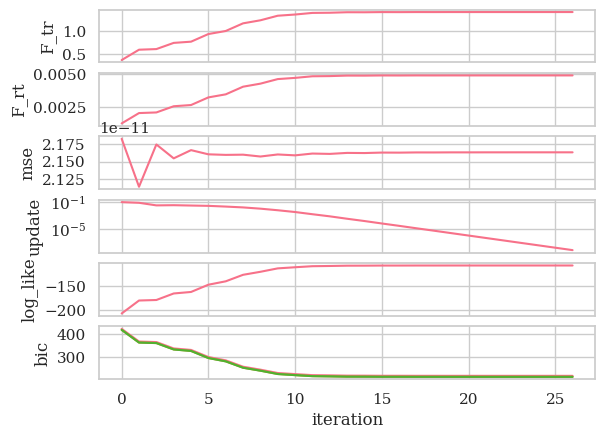

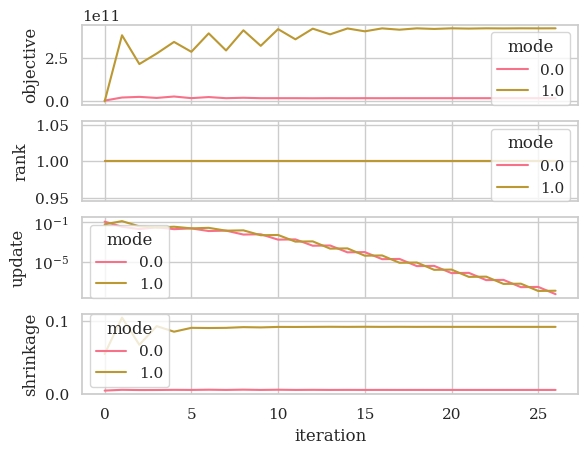

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(6,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='log_like', ax=axs[4])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='bic', ax=axs[5])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aic', ax=axs[5])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aicc', ax=axs[5])

    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[3])


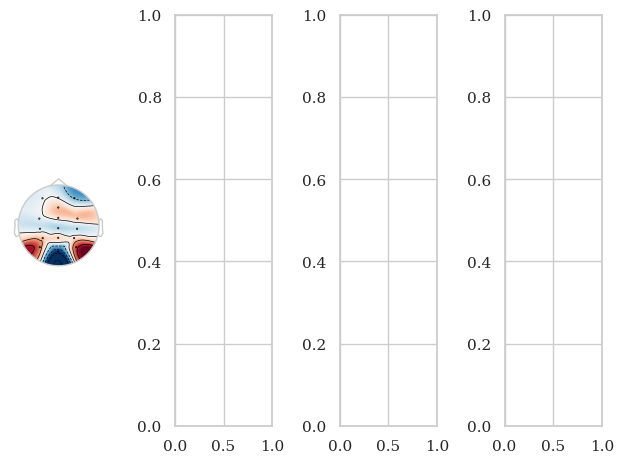

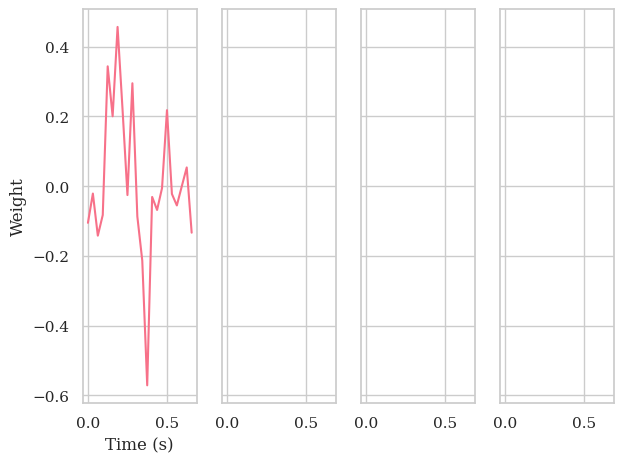

In [11]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


In [12]:
hoda.aps_

[array([[0.00781476],
        [0.07879307],
        [0.11725018],
        [0.0887058 ],
        [0.1071017 ],
        [0.13811216],
        [0.10290198],
        [0.1460492 ],
        [0.00150988],
        [0.00016768],
        [0.04518481],
        [0.07512331],
        [0.08932323],
        [0.07644283],
        [0.10347157],
        [0.12802753]]),
 array([[-0.26458185],
        [-0.08637581],
        [-0.1326171 ],
        [ 0.04178581],
        [ 0.49193627],
        [ 0.62020663],
        [ 0.80170767],
        [ 0.64253583],
        [ 0.20753674],
        [ 0.12170877],
        [-0.19229535],
        [-0.54073935],
        [-0.74936559],
        [-0.46435002],
        [-0.25286648],
        [-0.07388803],
        [ 0.10490518],
        [-0.03097761],
        [-0.13372858],
        [ 0.00576382],
        [ 0.01833939],
        [-0.07961591]])]

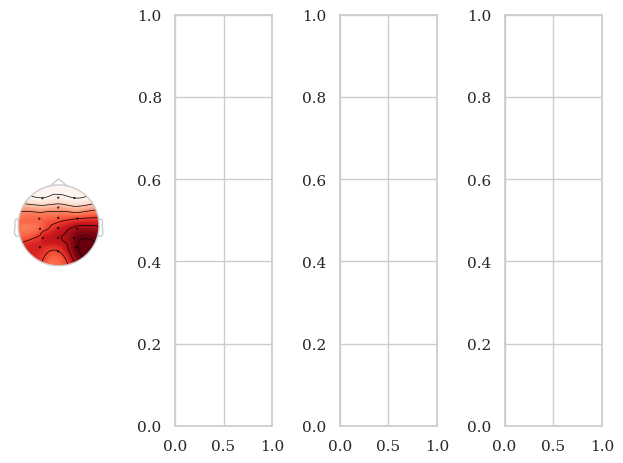

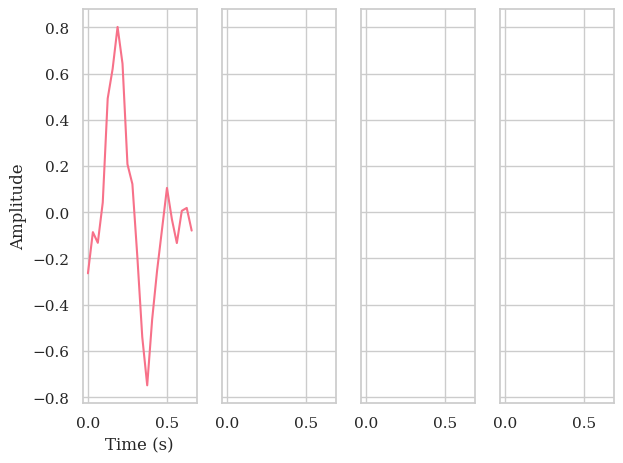

In [13]:

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


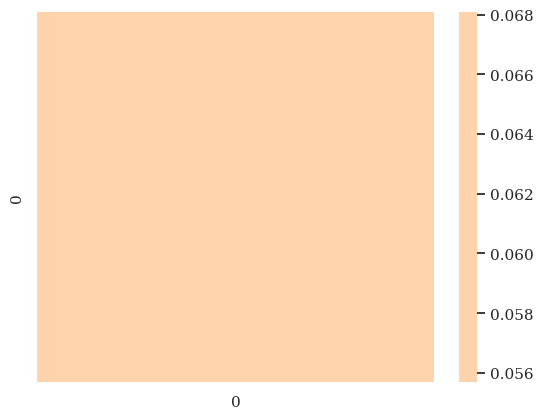

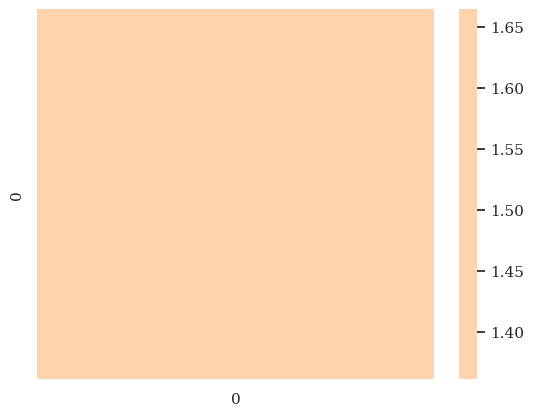

In [14]:
for k in range(2):
    sns.heatmap(tl.to_numpy(hoda.weights_[k].T@ hoda.aps_[k]), center=0)
    plt.show()


In [15]:
Xt = hoda.transform(X)

[[4.52463008e-74]]

[4.52463008e-74]

[4.52463008e-74]


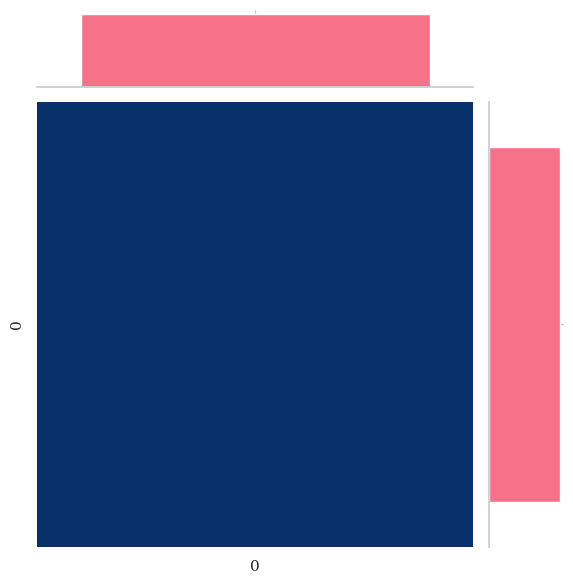

In [16]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)

In [17]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 1)

In [18]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


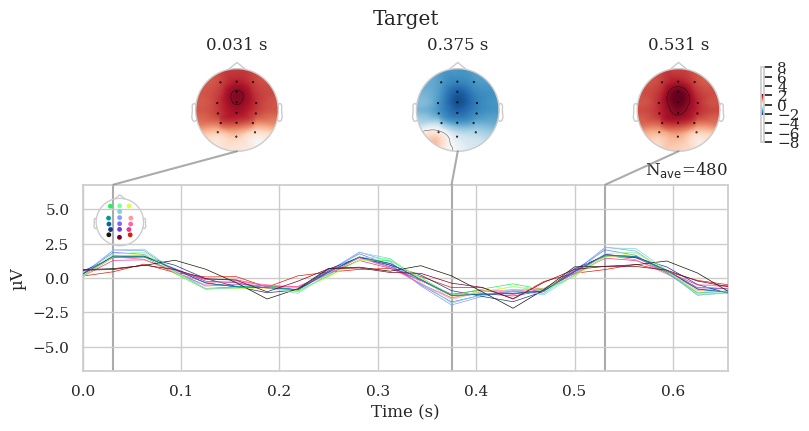

No projector specified for this dataset. Please consider the method self.add_proj.


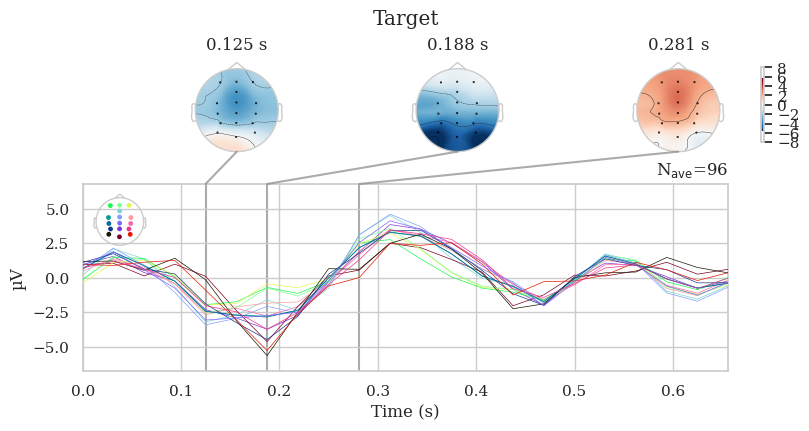

In [19]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_2395/286715887.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


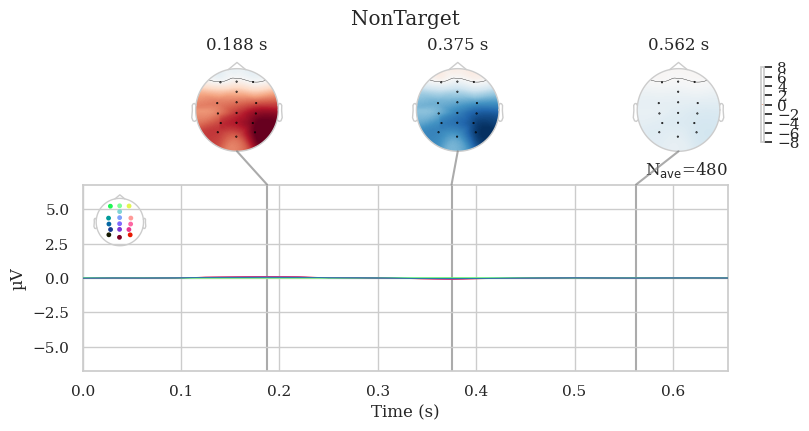

No projector specified for this dataset. Please consider the method self.add_proj.


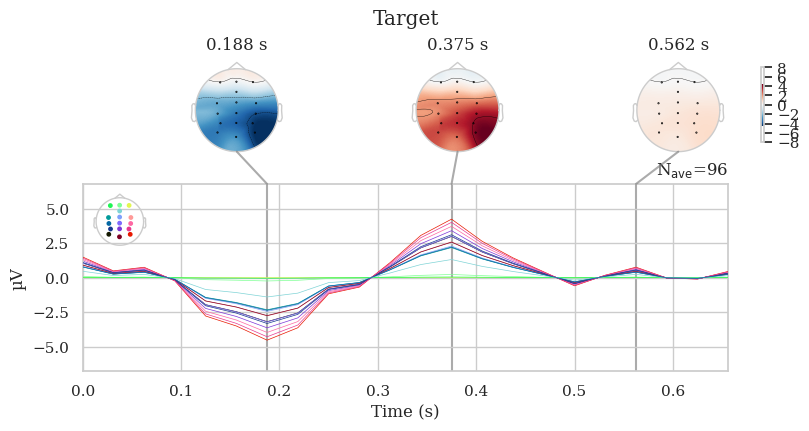

In [20]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


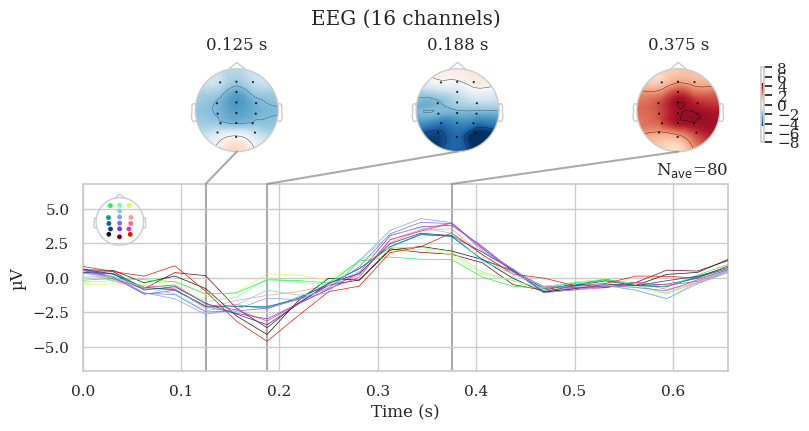

No projector specified for this dataset. Please consider the method self.add_proj.


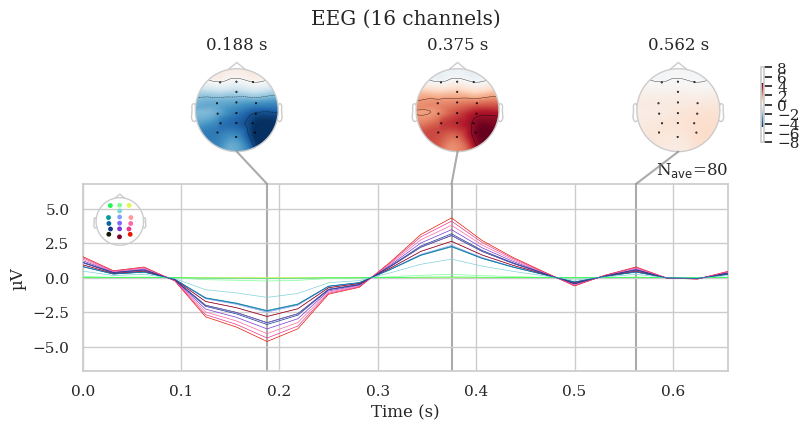

In [21]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


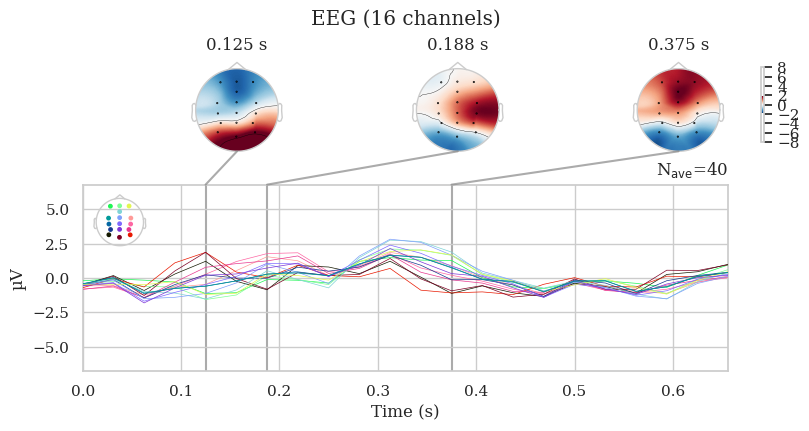

In [22]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)